# Experiment: Tutorial Round 1 EDA

Objective:
- Inspect price and trade behaviour for `EMERALDS` and `TOMATOES`.
- Produce a reusable workspace for follow-on feature engineering and strategy ideas.


In [1]:
# Setup: imports, paths, and plotting defaults
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from imc_eda.data import DEFAULT_DATA_DIR, build_price_features, load_prices, load_trades

sns.set_theme(style="whitegrid", context="notebook")
FIGURES_DIR = ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ROOT, DEFAULT_DATA_DIR


(PosixPath('/Users/shanilshah/Desktop/coding/imc prosperity'),
 PosixPath('/Users/shanilshah/Desktop/coding/imc prosperity/TUTORIAL_ROUND_1'))

## Plan

- Hypothesis: spread, imbalance, and trade flow should differ meaningfully by product.
- Variables to inspect: `mid_price`, `spread`, `book_imbalance`, trade price, and trade size.
- Metrics to record: row counts, time coverage, average spread, volatility, and trade notional.


In [2]:
# Load the raw parquet tutorial files and confirm the inventory
prices = build_price_features(load_prices(file_format="parquet"))
trades = load_trades(file_format="parquet")

inventory = pd.DataFrame(
    {
        "frame": ["prices", "trades"],
        "rows": [len(prices), len(trades)],
        "days": [prices["day"].nunique(), trades["day"].nunique()],
        "products": [
            sorted(prices["product"].unique().tolist()),
            sorted(trades["symbol"].unique().tolist()),
        ],
    }
)

display(inventory)
display(prices.head())
display(trades.head())


,frame,rows,days,products
0,prices,40000,2,"[EMERALDS, TOMATOES]"
1,trades,1219,2,"[EMERALDS, TOMATOES]"


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,ask_price_3,ask_volume_3,mid_price,profit_and_loss,source_file,spread,book_mid,total_bid_volume,total_ask_volume,book_imbalance
0,-2,0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,...,NaN,NaN,10000.0,0.0,prices_round_0_day_-2.parquet,16,10000.0,36.0,36.0,0.000000
1,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,...,NaN,NaN,5000.0,0.0,prices_round_0_day_-2.parquet,14,5000.0,24.0,24.0,0.000000
2,-2,100,EMERALDS,9992,15,9990,20,NaN,NaN,10008,...,NaN,NaN,10000.0,0.0,prices_round_0_day_-2.parquet,16,10000.0,35.0,35.0,0.000000
3,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,...,NaN,NaN,5002.5,0.0,prices_round_0_day_-2.parquet,9,5002.5,28.0,23.0,0.098039
4,-2,200,EMERALDS,9992,15,9990,30,NaN,NaN,10008,...,NaN,NaN,10000.0,0.0,prices_round_0_day_-2.parquet,16,10000.0,45.0,45.0,0.000000


,timestamp,buyer,seller,symbol,currency,price,quantity,day,source_file,notional
0,900,NaN,NaN,TOMATOES,XIRECS,5008.0,2,-2,trades_round_0_day_-2.parquet,10016.0
1,1700,NaN,NaN,TOMATOES,XIRECS,5006.0,3,-2,trades_round_0_day_-2.parquet,15018.0
2,4000,NaN,NaN,EMERALDS,XIRECS,10008.0,7,-2,trades_round_0_day_-2.parquet,70056.0
3,4100,NaN,NaN,TOMATOES,XIRECS,5002.0,3,-2,trades_round_0_day_-2.parquet,15006.0
4,5200,NaN,NaN,EMERALDS,XIRECS,9992.0,5,-2,trades_round_0_day_-2.parquet,49960.0


In [3]:
# Build quick summary tables for first-pass EDA
price_summary = (
    prices.groupby("product")
    .agg(
        observations=("mid_price", "size"),
        mean_mid_price=("mid_price", "mean"),
        mid_price_std=("mid_price", "std"),
        mean_spread=("spread", "mean"),
        mean_book_imbalance=("book_imbalance", "mean"),
    )
    .sort_index()
)

trade_summary = (
    trades.groupby("symbol")
    .agg(
        trades=("price", "size"),
        average_trade_price=("price", "mean"),
        total_quantity=("quantity", "sum"),
        total_notional=("notional", "sum"),
    )
    .sort_index()
)

display(price_summary.round(3))
display(trade_summary.round(3))


,observations,mean_mid_price,mid_price_std,mean_spread,mean_book_imbalance
product,,,,,
EMERALDS,20000,9999.998,0.723,15.738,-0.0
TOMATOES,20000,4992.758,19.747,13.020,-0.0


,trades,average_trade_price,total_quantity,total_notional
symbol,,,,
EMERALDS,399,9999.799,2189,21889688.0
TOMATOES,820,4992.572,2853,14245726.0


PosixPath('/Users/shanilshah/Desktop/coding/imc prosperity/reports/figures/quote-prices-vs-time-separate-assets.png')

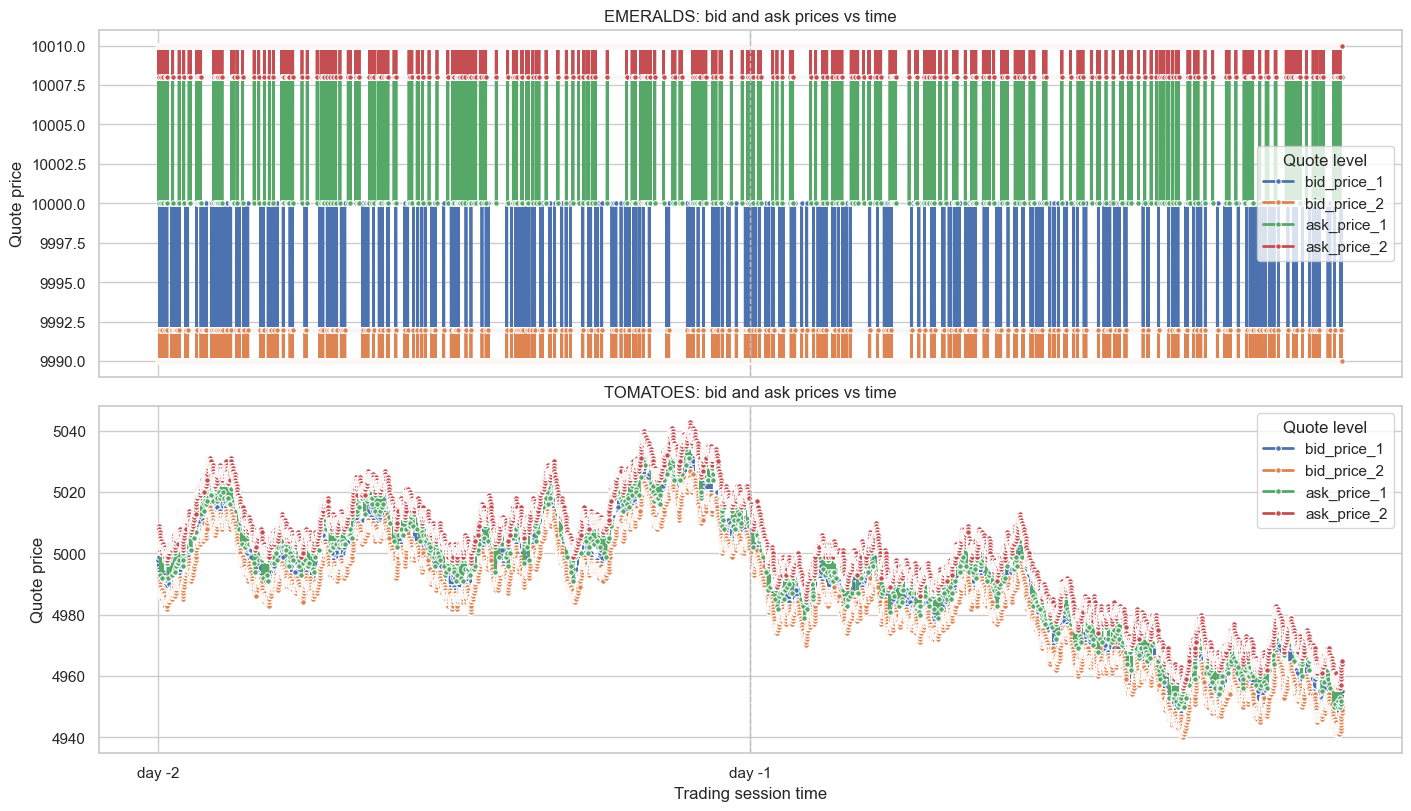

In [4]:
# Plot top-of-book quote prices against time in separate panels for each asset
quote_price_plot = (
    prices.groupby(["day", "timestamp", "product"], as_index=False)[["bid_price_1", "bid_price_2", "ask_price_1", "ask_price_2"]].mean()
    .sort_values(["day", "timestamp", "product"])
)

timestamp_step = (
    quote_price_plot.groupby("day")["timestamp"].diff().dropna().loc[lambda s: s > 0].min()
)
day_span = quote_price_plot["timestamp"].max() + (timestamp_step if pd.notna(timestamp_step) else 100)
quote_price_plot["session_time"] = (
    (quote_price_plot["day"] - quote_price_plot["day"].min()) * day_span + quote_price_plot["timestamp"]
)
quote_price_long = quote_price_plot.melt(
    id_vars=["day", "timestamp", "product", "session_time"],
    value_vars=["bid_price_1", "bid_price_2", "ask_price_1", "ask_price_2"],
    var_name="quote_level",
    value_name="quote_price",
).dropna(subset=["quote_price"])

products = sorted(quote_price_plot["product"].unique())
fig, axes = plt.subplots(len(products), 1, figsize=(14, 8), sharex=True, constrained_layout=True)
axes = [axes] if len(products) == 1 else axes

day_starts = quote_price_plot.groupby("day")["session_time"].min().sort_index()
for ax, product in zip(axes, products):
    product_data = quote_price_long[quote_price_long["product"] == product]
    sns.lineplot(
        data=product_data,
        x="session_time",
        y="quote_price",
        hue="quote_level",
        marker="o",
        markersize=4,
        linewidth=2,
        ax=ax,
    )
    for boundary in day_starts.iloc[1:]:
        ax.axvline(boundary, color="0.75", linestyle="--", linewidth=1)
    ax.set_title(f"{product}: bid and ask prices vs time")
    ax.set_ylabel("Quote price")
    ax.legend(title="Quote level")

axes[-1].set_xticks(day_starts.tolist())
axes[-1].set_xticklabels([f"day {day}" for day in day_starts.index])
axes[-1].set_xlabel("Trading session time")

figure_path = FIGURES_DIR / "quote-prices-vs-time-separate-assets.png"
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
figure_path


PosixPath('/Users/shanilshah/Desktop/coding/imc prosperity/reports/figures/quote-prices-vs-time-separate-assets-first-50.png')

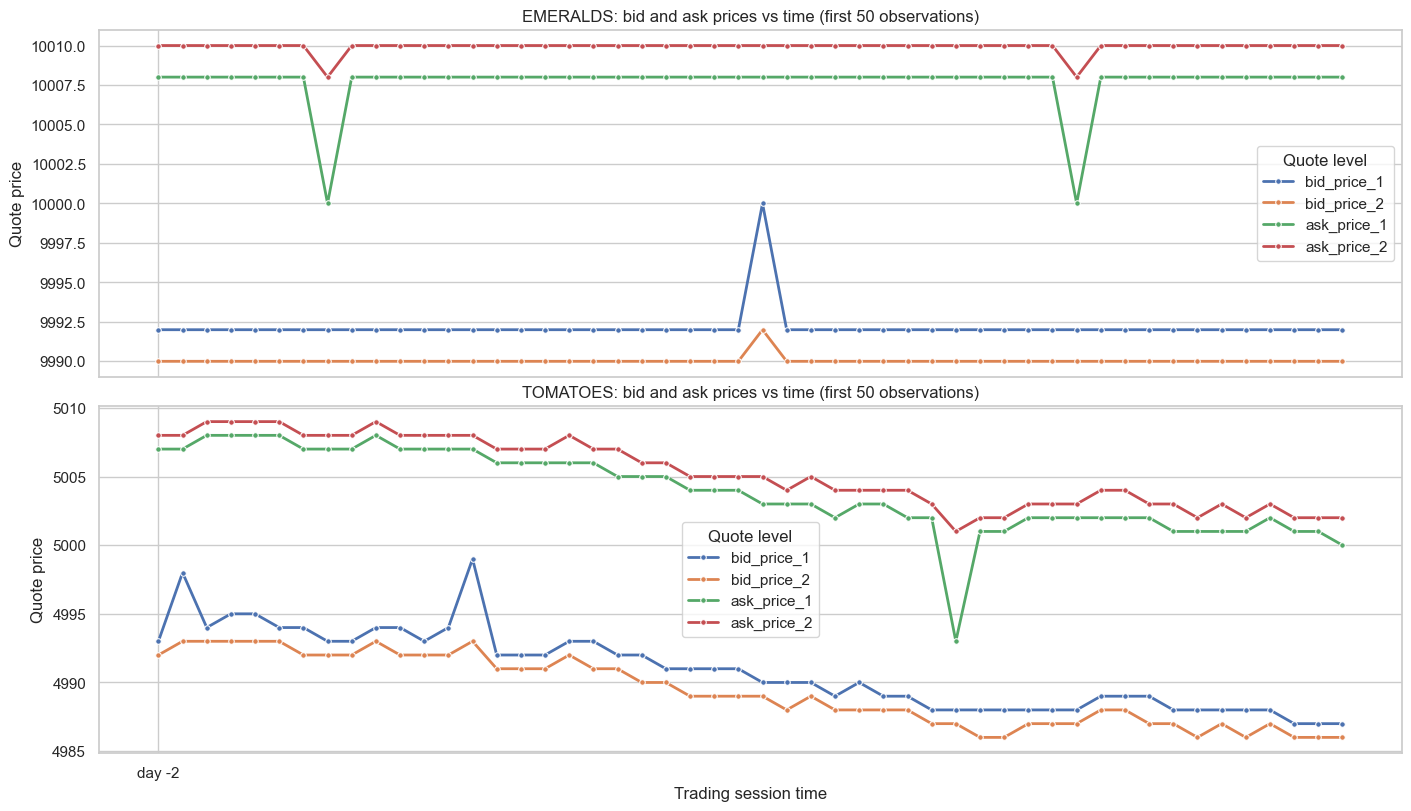

In [5]:
# Plot the first 50 observations for each asset with separate bid and ask lines
first_50_quote_price_plot = quote_price_plot.groupby("product", group_keys=False).head(50).copy()
first_50_quote_price_long = quote_price_long.groupby(["product", "quote_level"], group_keys=False).head(50).copy()

fig, axes = plt.subplots(len(products), 1, figsize=(14, 8), sharex=True, constrained_layout=True)
axes = [axes] if len(products) == 1 else axes

first_50_day_starts = first_50_quote_price_plot.groupby("day")["session_time"].min().sort_index()
for ax, product in zip(axes, products):
    product_data = first_50_quote_price_long[first_50_quote_price_long["product"] == product]
    sns.lineplot(
        data=product_data,
        x="session_time",
        y="quote_price",
        hue="quote_level",
        marker="o",
        markersize=4,
        linewidth=2,
        ax=ax,
    )
    for boundary in first_50_day_starts.iloc[1:]:
        ax.axvline(boundary, color="0.75", linestyle="--", linewidth=1)
    ax.set_title(f"{product}: bid and ask prices vs time (first 50 observations)")
    ax.set_ylabel("Quote price")
    ax.legend(title="Quote level")

axes[-1].set_xticks(first_50_day_starts.tolist())
axes[-1].set_xticklabels([f"day {day}" for day in first_50_day_starts.index])
axes[-1].set_xlabel("Trading session time")

figure_path_first_50 = FIGURES_DIR / "quote-prices-vs-time-separate-assets-first-50.png"
fig.savefig(figure_path_first_50, dpi=150, bbox_inches="tight")
figure_path_first_50


PosixPath('/Users/shanilshah/Desktop/coding/imc prosperity/reports/figures/trade-prices-vs-time-separate-assets.png')

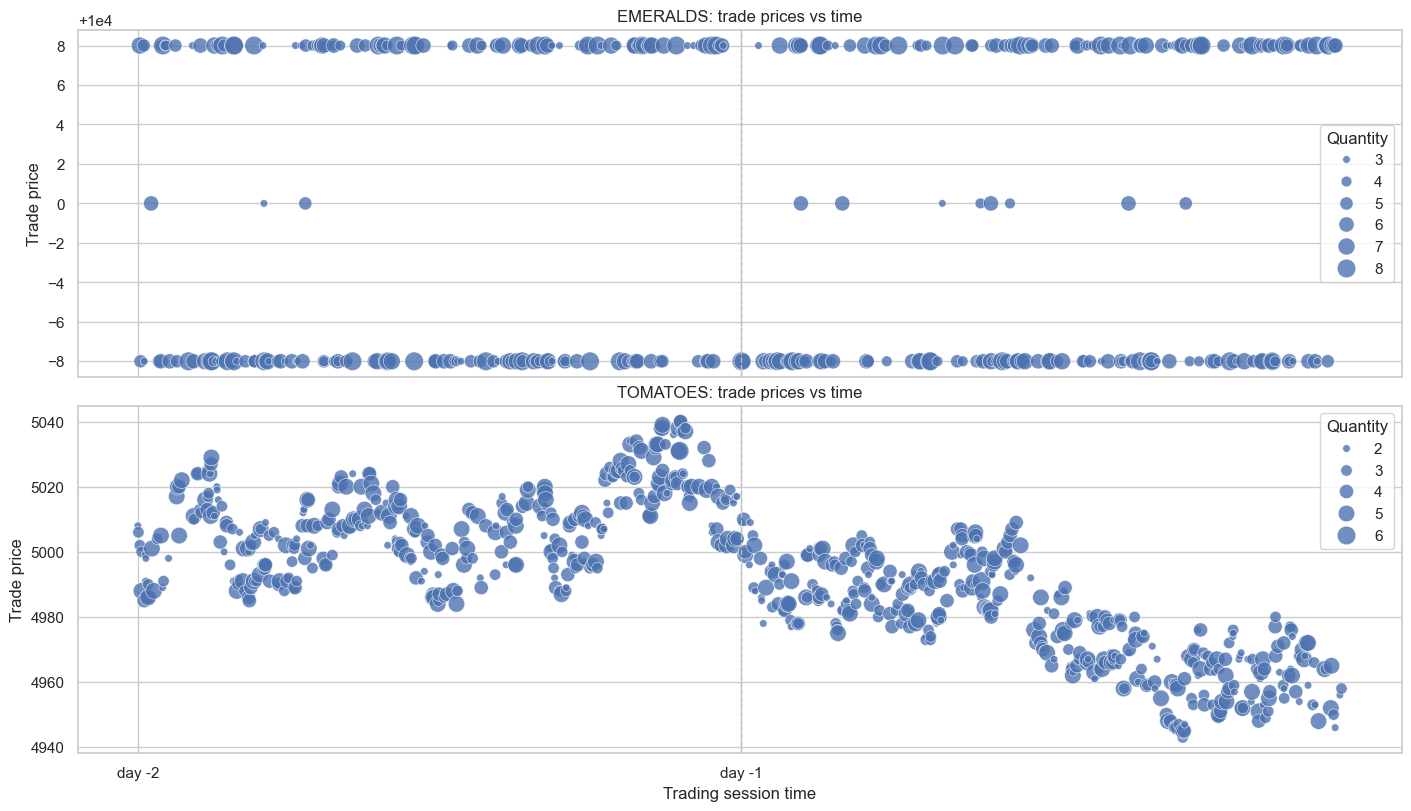

In [6]:
# Plot trade prices against time in separate panels for each asset
trade_price_plot = trades.sort_values(["day", "timestamp", "symbol", "price"]).copy()

trade_timestamp_step = (
    trade_price_plot.groupby("day")["timestamp"].diff().dropna().loc[lambda s: s > 0].min()
)
trade_day_span = trade_price_plot["timestamp"].max() + (trade_timestamp_step if pd.notna(trade_timestamp_step) else 100)
trade_price_plot["session_time"] = (
    (trade_price_plot["day"] - trade_price_plot["day"].min()) * trade_day_span + trade_price_plot["timestamp"]
)

trade_products = sorted(trade_price_plot["symbol"].unique())
fig, axes = plt.subplots(len(trade_products), 1, figsize=(14, 8), sharex=True, constrained_layout=True)
axes = [axes] if len(trade_products) == 1 else axes

trade_day_starts = trade_price_plot.groupby("day")["session_time"].min().sort_index()
for ax, product in zip(axes, trade_products):
    product_data = trade_price_plot[trade_price_plot["symbol"] == product]
    sns.scatterplot(
        data=product_data,
        x="session_time",
        y="price",
        size="quantity",
        sizes=(30, 180),
        alpha=0.8,
        ax=ax,
    )
    for boundary in trade_day_starts.iloc[1:]:
        ax.axvline(boundary, color="0.75", linestyle="--", linewidth=1)
    ax.set_title(f"{product}: trade prices vs time")
    ax.set_ylabel("Trade price")
    ax.legend(title="Quantity")

axes[-1].set_xticks(trade_day_starts.tolist())
axes[-1].set_xticklabels([f"day {day}" for day in trade_day_starts.index])
axes[-1].set_xlabel("Trading session time")

trade_figure_path = FIGURES_DIR / "trade-prices-vs-time-separate-assets.png"
fig.savefig(trade_figure_path, dpi=150, bbox_inches="tight")
trade_figure_path


## Results

- Key observations:
- Surprises or failure modes:
- Decision: continue, pivot, or stop:


In [7]:
# Capture the current state in a small structure you can grow over time
eda_notes = {
    "products": sorted(prices["product"].unique().tolist()),
    "days_covered": sorted(prices["day"].unique().tolist()),
    "price_rows": int(len(prices)),
    "trade_rows": int(len(trades)),
    "widest_average_spread_product": price_summary["mean_spread"].idxmax(),
}
eda_notes


{'products': ['EMERALDS', 'TOMATOES'],
 'days_covered': [-2, -1],
 'price_rows': 40000,
 'trade_rows': 1219,
 'widest_average_spread_product': 'EMERALDS'}

## Next steps

- Add product-specific plots for returns, volatility, and book imbalance.
- Join trades to the nearest quote snapshot if you want execution-quality analysis.
- Save any derived tables to `data/processed/` and exported charts to `reports/figures/`.
